In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pybird.module import interp1d
from pybird.correlator import Correlator

In [2]:
cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}
bias = {'b1': 2., 'b2': 0., 'b3': 0., 'b4': 0., 'cct': 0., 'cr1': 0., 'cr2': 0.}

h = cosmo['h'] # truth

In [3]:
z = 0.7
kk = np.geomspace(1.e-5, 2, 512) 
cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}

from pybird.symbolic import Symbolic

M = Symbolic()
M.set(cosmo)
M.compute(kk, z)
pk_lin = M.pk_lin
D1, f1 = M.D, M.f  # Growth factor and growth rate
H, DA = M.H, M.DA # AP parameters

### Baseline $k \, [h / \textrm{Mpc}], P(k) \, [h^{-3} \, \textrm{Mpc}^3]$, with fiducial AP (no $h$ conversion)

In [4]:
H_fid, DA_fid = H * 1.1, DA * 0.9
alpha_par, alpha_perp = H_fid / H, DA / DA_fid

In [5]:
N = Correlator()
N.set({'output': 'bPk', 'multipole': 3, 'z': z, 'kmax': 0.5, 'with_resum': False, 'with_ap': True, 'H_fid': 1., 'D_fid': 1.})
N.compute({'kk': kk, 'pk_lin': pk_lin, 'f': f1,
           'H': 1/alpha_par, 'DA': alpha_perp}) # notice the stupid PyBird convention
k = N.co.k
bpk = N.get(bias, what='linear')

### $k \, [h_{\rm fid} / \textrm{Mpc}], P(k) \, [h_{\rm fid}^{-3} \, \textrm{Mpc}^3]$ + $h$ conversion via AP 

In [6]:
h_fid = h * 1.1

In [7]:
def to_Mpc_per_h(_kk, _pk, h):
    ilogpk_ = interp1d(np.log(_kk), np.log(_pk), kind='linear', fill_value='extrapolate')
    return np.exp(ilogpk_(np.log(_kk*h))) * h**3

def to_Mpc(_kk, _pk, h):
    ilogpk_ = interp1d(np.log(_kk), np.log(_pk), kind='linear', fill_value='extrapolate')
    return np.exp(ilogpk_(np.log(_kk/h))) / h**3

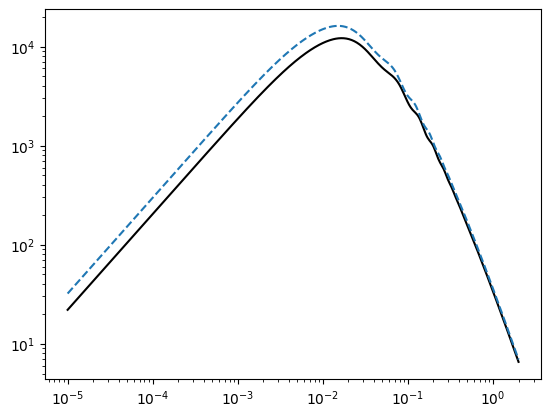

In [8]:
pk_mpc = to_Mpc(kk, pk_lin, h)
pk_h_fid = to_Mpc_per_h(kk, pk_mpc, h_fid)

plt.plot(kk, pk_lin, 'k')
plt.plot(kk, pk_h_fid, '--')
plt.xscale('log')
plt.yscale('log')


In [9]:
alpha_par_h_fid, alpha_perp_h_fid = alpha_par / (h / h_fid), alpha_perp / (h / h_fid)

In [10]:
N = Correlator()
N.set({'output': 'bPk', 'multipole': 3, 'z': z, 'kmax': 0.5, 'with_resum': False, 'with_ap': True, 'H_fid': 1., 'D_fid': 1.})
N.compute({'kk': kk, 'pk_lin': pk_h_fid, 'f': f1, 
            'H': 1/alpha_par_h_fid, 'DA': alpha_perp_h_fid}) # notice the stupid PyBird convention
bpk_2 = N.get(bias, what='linear')
k = N.co.k

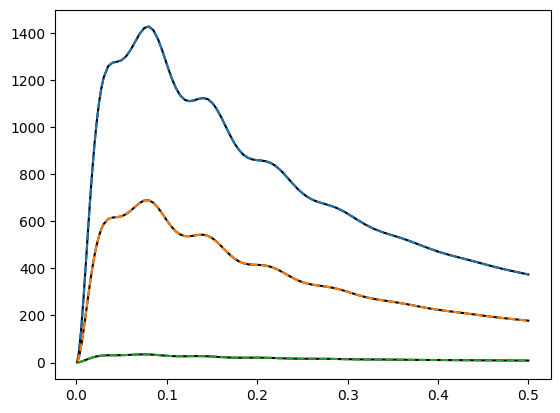

In [11]:
for i in range(3):
    plt.plot(k, k*bpk[i], 'k')
    plt.plot(k, k*bpk_2[i], '--')

(0.99, 1.01)

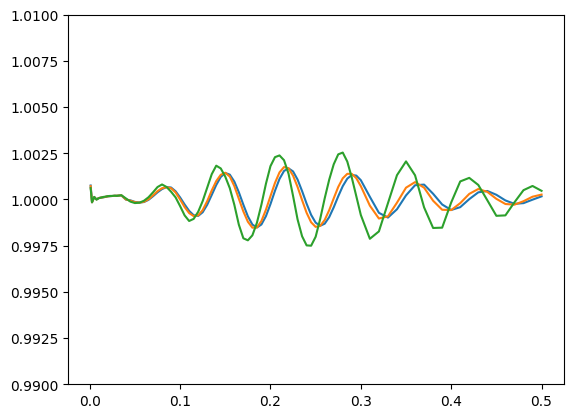

In [12]:
for i in range(3):
    plt.plot(k, bpk[i]/bpk_2[i])
plt.ylim(1-0.01, 1+0.01)